# Chapter: Feature Evaluation and Interpretability
## Feature Engineering & MLOps

**"We created 20 features. Which ones actually matter?"** This is one of the most common
questions in real ML work — and answering it wrong (or not at all) leads to bloated,
unmaintainable models and, worse, false confidence in features that aren't really doing
anything.

## Learning Objectives

By the end of this notebook, you should be able to:
- Explain the difference between built-in model importance, permutation importance, and SHAP
- Compute and interpret all three on the same model and dataset
- Explain the difference between GLOBAL and LOCAL interpretability
- Produce a plain-English explanation for one individual prediction
- Recognize the limitations of "importance" — including why it does NOT imply causality

## Real-World Problem

You work at a bank. Your team built a loan default model with **20 candidate features** —
credit score, income, employment history, existing debts, and more. The model works. But your
manager asks a simple, sharp question: *"Which of these 20 features are actually earning their
place? And if this applicant gets declined, what do we tell them?"*

- **Raw data available:** 20 columns per loan applicant (financial history, demographics, a
  few weaker/redundant columns mixed in).
- **Target:** `default` — did this loan go bad?
- **Why the business cares:** regulations in many countries require lenders to explain WHY an
  application was declined. A model that can't explain itself — even if accurate — may not be
  legally deployable. And a bloated 20-feature model that's really only using 5 of them is
  harder to maintain, audit, and trust than a lean one.

## Why Do We Need This Concept?

**Analogy:** imagine a group project where everyone gets the same final grade, but only 3 out
of 8 people actually did any work. Without some way to see individual contributions, you'd
never know who to thank — or who to stop including next time. Feature evaluation is exactly
that: dividing the model's "final grade" (its predictive performance) back among the
individual features that contributed to it.

**What happens if we skip this?** You keep maintaining, monitoring, and paying to collect data
for features that contribute nothing. Worse, you can't answer basic regulatory or business
questions like "why did the model decide this," which for many real applications (credit,
healthcare, hiring) isn't optional — it's a legal requirement.

## Concept Intuition

Three different tools answer "which features matter," each in a different way:

| Method | How it works | Speed | Trustworthiness |
|---|---|---|---|
| **Built-in importance** | Comes free from certain models (e.g., how much a feature reduced impurity across all tree splits) | Fast — no extra computation | Can be biased toward continuous/high-cardinality features |
| **Permutation importance** | Shuffle one feature's values, see how much performance drops | Moderate — needs repeated re-scoring | More reliable, model-agnostic |
| **SHAP** | Divides each individual PREDICTION's value among the features that produced it | Slower — game-theory based calculation | Most granular — works at both the whole-model AND single-prediction level |

**Analogy for SHAP specifically:** imagine dividing credit for a group project's final grade
among each team member, fairly, based on exactly how much each one's individual contribution
changed the outcome — that's what SHAP does for every single prediction a model makes.

## Tiny Manual Example

Imagine a model that predicts loan default using just 2 features, and we want to know which one
matters more. Here's the core idea behind **permutation importance**, worked by hand:

```
Step 1: Model's accuracy on the real data = 78%

Step 2: Shuffle (randomly reorder) the credit_score column only,
        breaking its real relationship with the target -- keep everything else the same.
        Model's accuracy on this shuffled data = 61%
        Drop = 78% - 61% = 17 percentage points  <- credit_score is IMPORTANT

Step 3: Now un-shuffle credit_score, and instead shuffle num_dependents only.
        Model's accuracy on THIS shuffled data = 77%
        Drop = 78% - 77% = 1 percentage point   <- num_dependents barely matters
```

**The logic:** if shuffling a feature barely hurts performance, the model wasn't relying on it
much in the first place. If shuffling it causes a big drop, the model was leaning on it heavily.
This is exactly what `permutation_importance` in scikit-learn automates — repeating this shuffle
many times per feature for a stable estimate, which we'll do next on our real 20-feature
dataset.

## Python Implementation

### Step 1 — Load the data and train a model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/loan_default_20features.csv")
print(df.shape)
df.head(3)

(1000, 21)


,customer_id,credit_score,annual_income,debt_to_income_ratio,employment_years,num_late_payments_12m,num_credit_lines,loan_amount,age,has_mortgage,...,monthly_expenses,savings_balance,num_previous_loans,avg_previous_loan_amount,region,credit_score_copy,random_noise_1,random_noise_2,random_noise_3,default
0,3,659,28200.0,0.542,10.1,1,4,7800.0,46,1,...,300.0,4450.0,1,19720.0,East,656.0,53.47,32.86,X,1
1,880,607,40800.0,0.313,5.0,0,13,12500.0,40,0,...,2770.0,1270.0,3,3250.0,North,605.0,63.99,50.93,Y,0
2,58,584,96600.0,0.375,2.3,1,6,5500.0,21,1,...,1400.0,11080.0,2,2580.0,South,590.0,41.51,74.38,Z,1


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

work = df.copy()
work["region_enc"] = LabelEncoder().fit_transform(work["region"])
work["noise3_enc"] = LabelEncoder().fit_transform(work["random_noise_3"])

feature_cols = [
    "credit_score", "annual_income", "debt_to_income_ratio", "employment_years",
    "num_late_payments_12m", "num_credit_lines", "loan_amount", "age", "has_mortgage",
    "num_dependents", "monthly_expenses", "savings_balance", "num_previous_loans",
    "avg_previous_loan_amount", "region_enc", "credit_score_copy",
    "random_noise_1", "random_noise_2", "noise3_enc",
]
print(f"{len(feature_cols)} candidate features")

X = work[feature_cols]
y = work["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"Test ROC-AUC: {test_auc:.3f}")

19 candidate features


Test ROC-AUC: 0.703


### Step 2 — Approach 1: Built-in (impurity-based) feature importance

Random Forest gives you this for free after training — no extra computation needed.

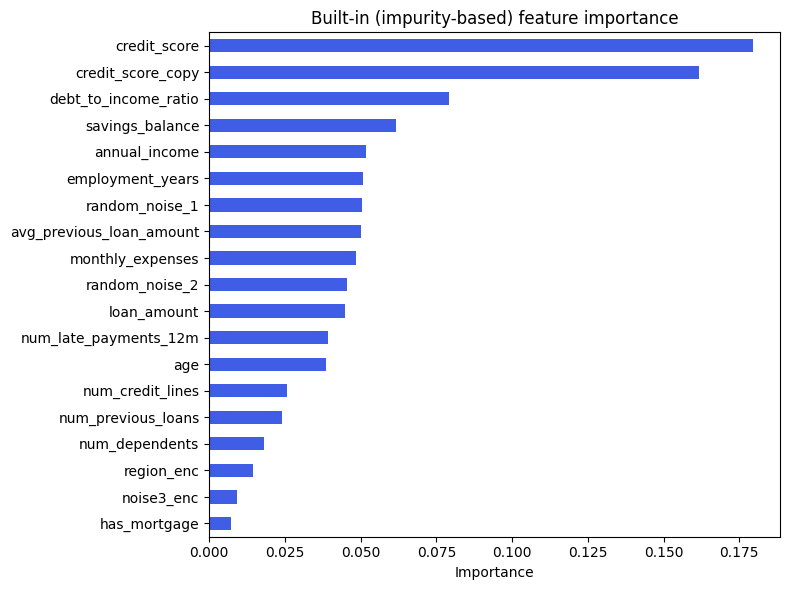

credit_score                0.179445
credit_score_copy           0.161601
debt_to_income_ratio        0.079170
savings_balance             0.061658
annual_income               0.051692
employment_years            0.050607
random_noise_1              0.050404
avg_previous_loan_amount    0.050265
monthly_expenses            0.048320
random_noise_2              0.045427
loan_amount                 0.044880
num_late_payments_12m       0.039340
age                         0.038699
num_credit_lines            0.025741
num_previous_loans          0.023864
num_dependents              0.018093
region_enc                  0.014534
noise3_enc                  0.009022
has_mortgage                0.007240
dtype: float64

In [3]:
builtin_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
builtin_importance.sort_values().plot(kind="barh", ax=ax, color="#405DE6")
ax.set_title("Built-in (impurity-based) feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

builtin_importance

**What should you notice?** `credit_score` and `credit_score_copy` (a near-duplicate we
planted on purpose) BOTH rank near the top, with similar importance — the model is splitting
credit between two columns that carry almost the same information. Also watch where
`random_noise_1` and `random_noise_2` land — they may rank suspiciously high, mixed in among
genuinely weaker legitimate features like `num_credit_lines` or `has_mortgage`. This is a known,
real limitation: impurity-based importance is **biased toward continuous, high-cardinality
features**, and pure noise columns are exactly that.

### Step 3 — Approach 2: Permutation importance

Instead of trusting the model's internal bookkeeping, we directly TEST each feature: shuffle
it, and measure how much test performance drops.

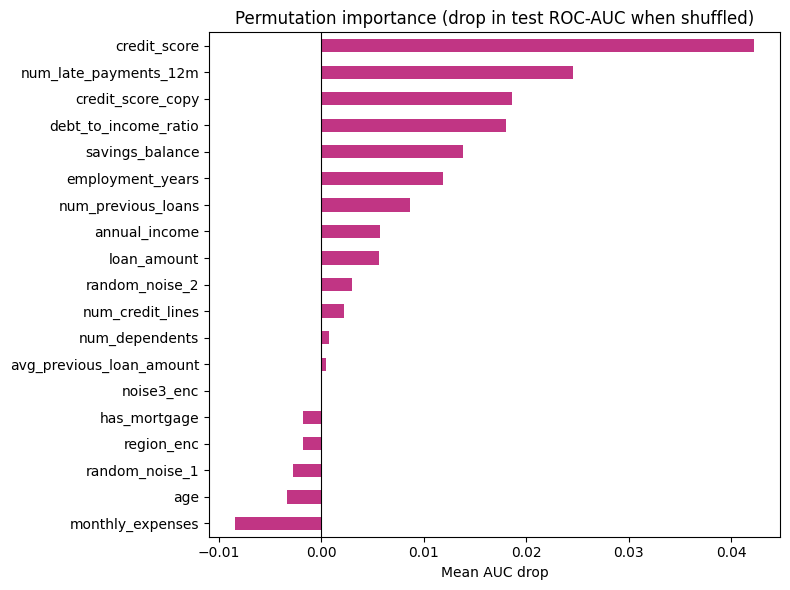

credit_score                0.042241
num_late_payments_12m       0.024532
credit_score_copy           0.018622
debt_to_income_ratio        0.018020
savings_balance             0.013874
employment_years            0.011854
num_previous_loans          0.008638
annual_income               0.005714
loan_amount                 0.005661
random_noise_2              0.003003
num_credit_lines            0.002215
num_dependents              0.000744
avg_previous_loan_amount    0.000425
noise3_enc                  0.000035
has_mortgage               -0.001816
region_enc                 -0.001816
random_noise_1             -0.002782
age                        -0.003384
monthly_expenses           -0.008399
dtype: float64

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    model, X_test, y_test, n_repeats=15, random_state=42, scoring="roc_auc"
)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
perm_importance.sort_values().plot(kind="barh", ax=ax, color="#C13584")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Permutation importance (drop in test ROC-AUC when shuffled)")
ax.set_xlabel("Mean AUC drop")
plt.tight_layout()
plt.show()

perm_importance

**What should you notice?** Compare this ranking to the built-in importance above. Both
`random_noise_1` and `random_noise_2` should now sit near the BOTTOM — some may even show a
slightly NEGATIVE value, meaning shuffling them didn't hurt performance at all (occasionally
even helped, by pure chance). `credit_score` should clearly be the single most important
feature by a wide margin, followed by `num_late_payments_12m` and `debt_to_income_ratio` — this
is a much cleaner, more trustworthy picture than the built-in importance gave us.

### Side-by-side comparison

In [5]:
comparison = pd.DataFrame({
    "builtin_importance": builtin_importance,
    "permutation_importance": perm_importance,
}).sort_values("permutation_importance", ascending=False)
comparison.round(4)

,builtin_importance,permutation_importance
credit_score,0.1794,0.0422
num_late_payments_12m,0.0393,0.0245
credit_score_copy,0.1616,0.0186
debt_to_income_ratio,0.0792,0.0180
savings_balance,0.0617,0.0139
employment_years,0.0506,0.0119
num_previous_loans,0.0239,0.0086
annual_income,0.0517,0.0057
loan_amount,0.0449,0.0057
random_noise_2,0.0454,0.0030


**The central lesson of this section:** the two methods can disagree — sometimes
substantially — on the SAME model and data. When they disagree, permutation importance is
generally the more trustworthy signal, because it directly measures the effect on actual
predictive performance, rather than relying on an internal (and sometimes biased) bookkeeping
mechanism.

### Step 4 — Approach 3: SHAP (SHapley Additive exPlanations)

**Analogy:** imagine dividing the model's prediction credit among the features — fairly, the
same way you'd divide credit for a group project's outcome among team members, based on exactly
how much each one's individual contribution changed the result.

SHAP goes further than the two methods above: it explains not just "which features matter
overall" (**global**), but "why did the model make THIS SPECIFIC prediction, for this one
applicant" (**local**) — both from the same underlying calculation.

In [6]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:300])

# For binary classification, shap_values has shape (rows, features, classes) --
# we want the "default = 1" class
shap_values_default = shap_values[:, :, 1]
print("SHAP values shape:", shap_values_default.shape)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (250, 19)


#### Global interpretability: which features matter across ALL predictions?

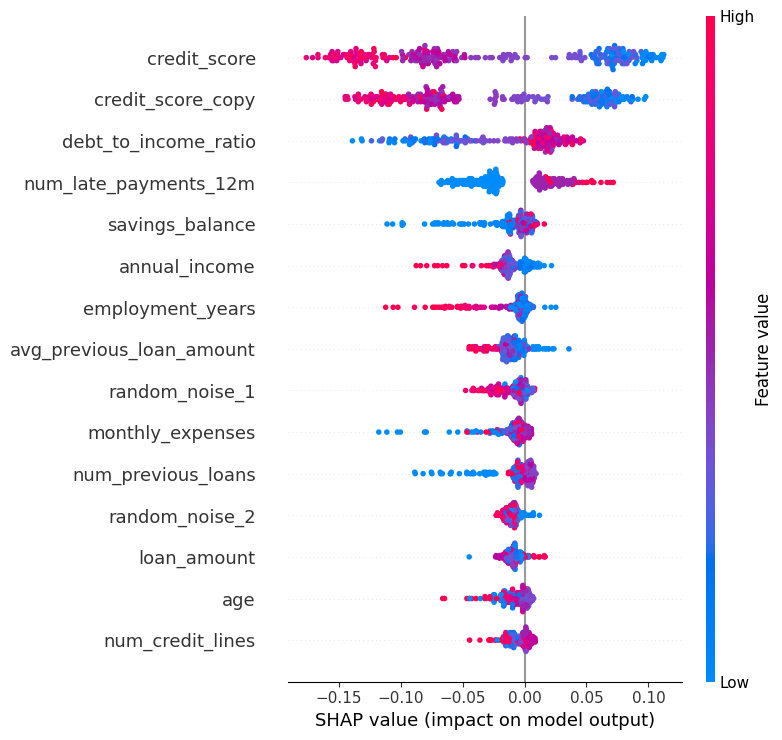

In [7]:
shap.summary_plot(shap_values_default, X_test.iloc[:300], feature_names=feature_cols,
                   show=False, max_display=15)
plt.tight_layout()
plt.show()

**What should you notice?** Each dot is one applicant. Red = a high value of that feature
for that applicant, blue = a low value. `credit_score` should show a clean pattern: red
(high credit score) dots pushing LEFT (toward lower default risk), blue (low score) dots
pushing RIGHT (toward higher risk) — matching both intuition and what permutation importance
already told us. This agreement across three DIFFERENT methods (built-in was the outlier,
permutation and SHAP agree) is itself a strong signal that `credit_score` is genuinely
important, not a fluke of one particular method.

In [8]:
shap_ranking = pd.Series(
    np.abs(shap_values_default).mean(axis=0), index=feature_cols
).sort_values(ascending=False)
shap_ranking

credit_score                0.085719
credit_score_copy           0.071896
debt_to_income_ratio        0.037889
num_late_payments_12m       0.030749
savings_balance             0.014517
annual_income               0.013351
employment_years            0.013196
avg_previous_loan_amount    0.012799
random_noise_1              0.010871
monthly_expenses            0.010765
num_previous_loans          0.010349
random_noise_2              0.010255
loan_amount                 0.009956
age                         0.009749
num_credit_lines            0.007508
has_mortgage                0.005403
region_enc                  0.004257
noise3_enc                  0.003861
num_dependents              0.003676
dtype: float64

#### Local interpretability: why did the model decide THIS ONE prediction?

This applicant's predicted default probability: 24.1%
Actual outcome: Defaulted


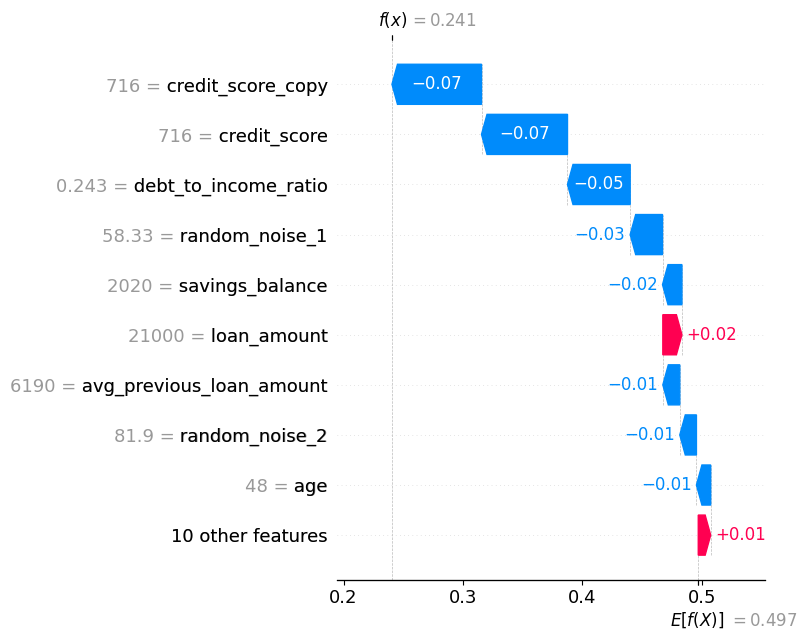

In [9]:
# Pick one specific applicant and explain their individual prediction
sample_idx = 0
applicant_data = X_test.iloc[sample_idx]
predicted_prob = model.predict_proba(X_test.iloc[[sample_idx]])[0, 1]

print(f"This applicant's predicted default probability: {predicted_prob:.1%}")
print(f"Actual outcome: {'Defaulted' if y_test.iloc[sample_idx] == 1 else 'No default'}")

explanation = shap.Explanation(
    values=shap_values_default[sample_idx],
    base_values=explainer.expected_value[1],
    data=applicant_data.values,
    feature_names=feature_cols,
)
shap.plots.waterfall(explanation, max_display=10, show=False)
plt.tight_layout()
plt.show()

**What should you notice?** This chart is the answer to "why did the model decide THIS
specific prediction" — each bar shows exactly how much one feature pushed this ONE applicant's
predicted risk up (red) or down (blue) from the model's average starting point. This is exactly
the kind of explanation a bank could show a regulator, or even the applicant themselves —
something neither built-in importance nor permutation importance can produce, since both only
describe the model's behavior OVERALL, never for one individual case.

### Comparing all three methods

In [10]:
final_comparison = pd.DataFrame({
    "builtin": builtin_importance,
    "permutation": perm_importance,
    "shap": shap_ranking,
}).sort_values("shap", ascending=False)
final_comparison.round(4)

,builtin,permutation,shap
credit_score,0.1794,0.0422,0.0857
credit_score_copy,0.1616,0.0186,0.0719
debt_to_income_ratio,0.0792,0.0180,0.0379
num_late_payments_12m,0.0393,0.0245,0.0307
savings_balance,0.0617,0.0139,0.0145
annual_income,0.0517,0.0057,0.0134
employment_years,0.0506,0.0119,0.0132
avg_previous_loan_amount,0.0503,0.0004,0.0128
random_noise_1,0.0504,-0.0028,0.0109
monthly_expenses,0.0483,-0.0084,0.0108


## Industry Case Study

**Banking — regulatory model explainability.** Under fair-lending regulations in many
countries, a bank that declines a loan application must be able to tell the applicant WHY —
not just "the model said so." A bank's model risk management team typically requires:

```
RAW DATA                FEATURE                MODEL              BUSINESS DECISION
---------                -------                -----              ------------------
credit bureau      -->   credit_score,     -->  predicts     -->   approve / decline,
records, income           debt_to_income          default          WITH a SHAP-based
verification, loan        ratio, late                              explanation attached
history                   payments                                 ("declined primarily due
                                                                     to late payment history
                                                                     and high existing debt")
```

Global SHAP importance satisfies the model risk team's question ("what does this model
generally rely on?"). Local SHAP explanations satisfy the individual applicant's question
("why was MY application declined?"). Built-in and permutation importance can only ever answer
the first question — this is exactly why SHAP has become close to an industry standard for
regulated lending models specifically.

## What Can Go Wrong? (Limitations)

**Limitation 1 — Correlation, not causation**

- **Problem:** a feature scoring high in SHAP/importance means the model FOUND it useful for
  prediction — it does NOT mean that feature CAUSES the outcome.
- **Why it happens:** it's tempting to read "important feature" as "root cause," especially
  when presenting results to non-technical stakeholders.
- **Example:** `savings_balance` might rank as important for predicting default, but low
  savings doesn't necessarily CAUSE default — both might be driven by a third factor (like
  irregular income) that isn't even in the dataset.
- **How to detect it:** ask whether there's a plausible causal mechanism, or just a
  statistical association, before making any causal claim.
- **How to fix it:** be explicit, every time you report importance, that you're describing
  PREDICTIVE usefulness, not a causal driver — those require a different kind of study entirely
  (e.g., a controlled experiment).

**Limitation 2 — Importance doesn't mean business causality**

- **Problem:** even a feature that's causally related to the outcome may not be something the
  business can or should ACT on.
- **Why it happens:** "important for prediction" and "actionable business lever" are different
  questions entirely.
- **Example:** `age` might be genuinely predictive of default risk, but a bank cannot (and
  should not) use age as grounds for a lending decision — that's illegal age discrimination in
  most jurisdictions, regardless of what the model found statistically useful.
- **How to fix it:** always pair statistical importance with a business/legal/ethical review
  before acting on any feature's ranking.

**Limitation 3 — Interpretation depends on the model and the data**

- **Problem:** the SAME dataset can produce DIFFERENT importance rankings depending on which
  model you use (we already saw built-in vs. permutation disagree on the SAME model).
- **Why it happens:** different models capture different kinds of relationships (linear vs.
  non-linear, interactions vs. none), so "importance" is always relative to a SPECIFIC model,
  not an absolute property of the data.
- **How to fix it:** never present feature importance as a universal truth about the data —
  always specify which model and which method produced the ranking you're showing.

## Mini Exercise

**Try this yourself before looking at the solution.**

Your model ranks `annual_income` as the #2 most important feature (by SHAP) for predicting loan
default. Your manager says: *"Great, let's raise the minimum income requirement for all
applicants — that should reduce defaults."* What would you say before agreeing to that plan?

## Exercise Solution

Before agreeing, raise these points:

1. **Importance ≠ a simple threshold rule.** The model found `annual_income` useful in
   COMBINATION with other features (debt-to-income ratio, credit score, etc.) — it doesn't
   mean "higher income always means lower risk" in isolation. A high-income applicant with a
   very high debt-to-income ratio could still be high risk.
2. **Check the SHAP dependence pattern**, not just the overall importance rank — does risk
   actually decrease smoothly as income rises, or is the relationship more complicated (e.g.,
   flat above a certain income, or only mattering for certain loan amounts)?
3. **This is a policy change, not a modeling change** — raising a minimum income requirement
   could have fair-lending implications (income correlates with factors like age, location, or
   other protected characteristics) that need legal review, independent of what the model found
   statistically.
4. **Correlation vs. causation, again** — even if income and default are strongly related in
   this data, that doesn't prove that RAISING income (which isn't what the policy actually
   does — it excludes low-income applicants, it doesn't raise anyone's income) reduces default
   RATES; it may simply exclude a segment of applicants who were actually low-risk for other
   reasons entirely.

## Interview Questions

**1. (Conceptual) What's the difference between built-in feature importance and permutation
importance?**
> Built-in importance (e.g., a Random Forest's `feature_importances_`) comes from internal
> bookkeeping during training (how much each feature reduced impurity across splits) and can be
> biased toward continuous/high-cardinality features. Permutation importance directly measures
> the drop in actual test performance when a feature is shuffled — slower to compute, but more
> trustworthy.

**2. (Conceptual) What does SHAP stand for, and what does it compute?**
> SHapley Additive exPlanations. It divides each individual prediction's value fairly among the
> features that produced it, based on game-theoretic Shapley values, giving both a global
> (whole-model) and local (single-prediction) view.

**3. (Practical) Your model says `income` is the most important feature. Does that mean income
CAUSES loan default?**
> No. Importance reflects predictive usefulness within this specific model, not a causal
> relationship. Income could be correlated with the true cause (e.g., irregular employment)
> without causing default itself. Establishing causality requires a different kind of analysis
> (e.g., a controlled experiment), not just feature importance.

**4. (Practical) When would you use a LOCAL explanation instead of a GLOBAL one?**
> When you need to explain one SPECIFIC decision — e.g., telling an individual applicant why
> their loan was declined — rather than describing the model's general behavior across all
> applicants.

**5. (Scenario) Two importance methods disagree on the same model and data. Which do you trust
more, and why?**
> Generally permutation importance or SHAP over built-in impurity-based importance, since both
> directly measure the effect on real predictive performance rather than relying on
> training-time bookkeeping that can carry known biases.

**6. (Practical) Why might a redundant, near-duplicate feature (like our `credit_score_copy`)
show up as "important" in more than one method?**
> Because the model may split credit for the same real signal between the two duplicate
> columns rather than picking one cleanly — both end up looking moderately important, even
> though together they only represent ONE genuine piece of information.

**7. (Conceptual) Why is correlation not causation especially important to remember in feature
interpretability?**
> Because stakeholders often want to ACT on important features (e.g., "let's require higher
> income"), and acting on a correlational signal as if it were causal can produce policies that
> don't actually reduce risk, or that create legal/ethical problems (e.g., discrimination).

**8. (Interview exercise) Your model says income is the most important feature. Does that mean
income causes default? Walk through your full reasoning, not just yes/no.**
> See the Mini Exercise Solution above — the reasoning should cover: importance reflects
> predictive usefulness within a specific model/dataset, not causation; the feature likely
> works in combination with others, not in isolation; any resulting policy needs separate
> legal/business review; and correlation with a true underlying cause is not the same as being
> that cause.

## Assignment (30-60 minutes)

Using `loan_default_20features.csv` from this chapter:

1. Train a `LogisticRegression` model (instead of Random Forest) on the same 19 features.
2. Compute permutation importance for this new model.
3. Compare the top 5 features by permutation importance between your Logistic Regression model
   and the Random Forest model already in this notebook. Do they agree?
4. Pick ONE feature where the two models disagree most, and write 2-3 sentences hypothesizing
   why a linear model and a tree-based model might value that feature differently.

## Key Takeaways

- Built-in importance is fast but can be biased toward continuous/high-cardinality features.
- Permutation importance directly tests each feature by shuffling it — slower, but more reliable.
- SHAP provides both global (whole-model) and local (single-prediction) explanations from one
  underlying calculation.
- When methods disagree, that disagreement itself is informative — don't just pick whichever
  ranking you like best.
- Feature importance measures predictive usefulness for a SPECIFIC model — never causality, and
  never automatic business justification for acting on a feature.
- Always pair statistical importance with business, legal, and ethical review before acting on
  any feature's ranking, especially in regulated domains like lending.

## Final Challenge

A healthcare provider builds a model predicting 30-day hospital readmission risk, using 25
features including `zip_code`, `num_prior_admissions`, `length_of_stay`, `discharge_medication_count`,
and `insurance_type`. Using everything from this chapter:

1. Which of these features would you specifically scrutinize for the "correlation vs.
   causation" and "business/legal appropriateness" limitations discussed above, and why?
2. Describe how you would use SHAP to explain ONE individual patient's readmission risk score
   to a treating physician, in language a non-technical clinician would understand.
3. Propose one concrete way you'd check whether your permutation importance ranking is stable
   (not just a fluke of one particular train/test split).